In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets , transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix , classification_report

In [18]:
transform  = transforms.Compose([transforms.ToTensor() ,  transforms.Normalize((0.1307,), (0.3081,))])

In [19]:
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)

In [20]:
#Prepare Data

train_loader = DataLoader(dataset=train_dataset , batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset , batch_size=64, shuffle=False)



# CNN

In [21]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1,16,3 , padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.fc1 = nn.Linear(32*7*7,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32*7*7)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

In [22]:
model = CNN()

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [24]:
epochs  = 20
train_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images , labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss/len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}: Training Loss: {avg_loss}")

Epoch 1: Training Loss: 0.16249011830637244
Epoch 2: Training Loss: 0.048416963206784826
Epoch 3: Training Loss: 0.03423754661278834
Epoch 4: Training Loss: 0.02465398375122775
Epoch 5: Training Loss: 0.019488939044630102
Epoch 6: Training Loss: 0.016001807211956973
Epoch 7: Training Loss: 0.012546360773439583
Epoch 8: Training Loss: 0.0099276318819192
Epoch 9: Training Loss: 0.0106561538713931
Epoch 10: Training Loss: 0.008502110275664635
Epoch 11: Training Loss: 0.005740568640000504
Epoch 12: Training Loss: 0.006532979544701121
Epoch 13: Training Loss: 0.0046693485114291345
Epoch 14: Training Loss: 0.0063758239011741085
Epoch 15: Training Loss: 0.0047525057526909675
Epoch 16: Training Loss: 0.004599421584478119
Epoch 17: Training Loss: 0.00452078666076961
Epoch 18: Training Loss: 0.0031432427512016604
Epoch 19: Training Loss: 0.004573920266746815
Epoch 20: Training Loss: 0.00431752689978663


Text(0.5, 0, 'Epochs')

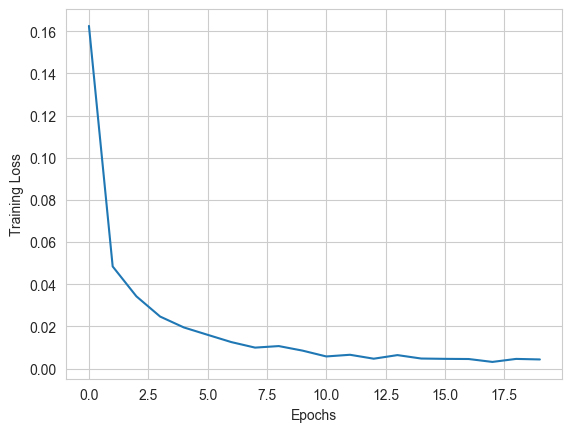

In [25]:
plt.plot(train_losses)
plt.ylabel('Training Loss')
plt.xlabel('Epochs')

In [35]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images , labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs , 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

print("\nClassification Report")
print(classification_report(all_labels, all_preds))


Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      0.99      1.00      1135
           2       0.98      1.00      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      1.00      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.98      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



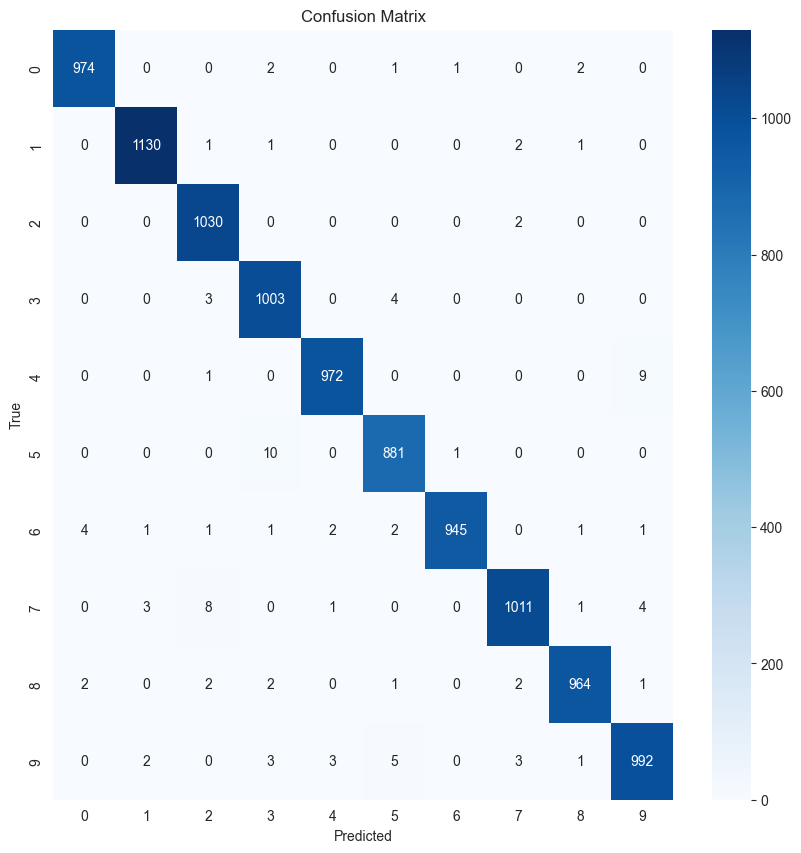

In [27]:
conf_matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,10))
sns.heatmap(conf_matrix, annot=True, cmap="Blues" , fmt="d" , xticklabels=range(10) , yticklabels=range(10))
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [32]:
class CNN_RNN(nn.Module):
    def __init__(self, hidden_size=128, num_layers=2, num_classes=10):
        super().__init__()

        # CNN block
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # (batch, 32, 28, 28)
            nn.ReLU(),
            nn.MaxPool2d(2),                               # (batch, 32, 14, 14)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # (batch, 64, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(2)                                # (batch, 64,  7,  7)
        )

        # RNN input_size = 64 channels * 7 width = 448
        # sequence length = 7 (height after pooling)
        self.rnn = nn.LSTM(
            input_size=64 * 7,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3
        )

        self.fc = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # x: (batch, 1, 28, 28)
        x = self.cnn(x)                        # (batch, 64, 7, 7)

        batch, channels, h, w = x.size()
        x = x.permute(0, 2, 1, 3)             # (batch, 7, 64, 7)
        x = x.reshape(batch, h, channels * w) # (batch, 7, 448)  <- sequence

        out, (h_n, c_n) = self.rnn(x)         # out: (batch, 7, hidden_size)
        out = self.dropout(out[:, -1, :])      # last timestep: (batch, hidden_size)
        return self.fc(out)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = CNN_RNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train(epoch):
    model.train()
    total_loss, correct = 0, 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += output.argmax(1).eq(target).sum().item()
    print(f'Epoch {epoch} | Loss: {total_loss/len(train_loader):.4f} | Train Acc: {correct/len(train_loader.dataset):.4f}')

def evaluate():
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            correct += model(data).argmax(1).eq(target).sum().item()
    print(f'Test Accuracy: {correct/len(test_loader.dataset):.4f}')

for epoch in range(1, 11):
    train(epoch)
evaluate()

Epoch 1 | Loss: 0.2790 | Train Acc: 0.9133
Epoch 2 | Loss: 0.0628 | Train Acc: 0.9821
Epoch 3 | Loss: 0.0444 | Train Acc: 0.9871
Epoch 4 | Loss: 0.0337 | Train Acc: 0.9899
Epoch 5 | Loss: 0.0251 | Train Acc: 0.9926
Epoch 6 | Loss: 0.0222 | Train Acc: 0.9935
Epoch 7 | Loss: 0.0189 | Train Acc: 0.9944
Epoch 8 | Loss: 0.0167 | Train Acc: 0.9950
Epoch 9 | Loss: 0.0133 | Train Acc: 0.9960
Epoch 10 | Loss: 0.0140 | Train Acc: 0.9958
Test Accuracy: 0.9920


# BOTH CNN & RNN ARE ABLE TO ACHIEVE 99% ACCURACY